# Figure 1 — PCA and Volcano Plots

Principal component analysis (PCA) and volcano plots comparing control vs. fermented samples for cassava and cocoyam. PCA is computed on log2-normalized intensities after standard scaling. Volcano plots show log2 fold-change vs. −log10(FDR-adjusted p-value), with significance thresholds at p < 0.05 and |log2FC| > 1.

**Output:** `figure1_complete.svg / .png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from upsetplot import UpSet, from_memberships
from matplotlib_venn import venn2, venn2_circles
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

# Output directory
OUTPUT_DIR = '../figures/separate_treatment'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Analysis parameters
PROB_CUTOFF = 0.7
FDR_CUTOFF = 0.05
LOG2FC_THRESHOLD = 1.0

print(f"Output directory: {OUTPUT_DIR}")
print(f"Probability cutoff: {PROB_CUTOFF}")
print(f"FDR cutoff: {FDR_CUTOFF}")
print(f"log2FC threshold: {LOG2FC_THRESHOLD}")

Output directory: ../figures/separate_treatment
Probability cutoff: 0.7
FDR cutoff: 0.05
log2FC threshold: 1.0


In [2]:
# ── Load cassava-only data ─────────────────────────────────────────────────────
cassava_quant = pd.read_csv('../results/b3_cassavaonly_feature_list_imputed_log2.csv')
cassava_fdr = pd.read_csv('../results/b3_cassavaonly_fdr_cassava_vs_fermented_cassava.csv')
cassava_ms2 = pd.read_csv('../results/b3_cassavaonly_ms2_annotations.csv')

# ── Load cocoyam-only data ─────────────────────────────────────────────────────
cocoyam_quant = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cocoyam_fdr = pd.read_csv('../results/b3_cocoyamonly_fdr_cocoyam_vs_fermented_cocoyam.csv')
cocoyam_ms2 = pd.read_csv('../results/b3_cocoyamonly_ms2_annotations.csv')

print("=== Cassava-only data ===")
print(f"  Features: {len(cassava_quant):,}")
print(f"  FDR results: {len(cassava_fdr):,}")
print(f"  MS2 annotations: {len(cassava_ms2):,}")

print("\n=== Cocoyam-only data ===")
print(f"  Features: {len(cocoyam_quant):,}")
print(f"  FDR results: {len(cocoyam_fdr):,}")
print(f"  MS2 annotations: {len(cocoyam_ms2):,}")

=== Cassava-only data ===
  Features: 3,324
  FDR results: 3,324
  MS2 annotations: 1,482

=== Cocoyam-only data ===
  Features: 4,437
  FDR results: 4,437
  MS2 annotations: 1,840


In [3]:
def create_volcano_plot(data, title, log2fc_threshold=1.0, pvalue_threshold=0.05):
    """
    Create a volcano plot for differential metabolite analysis.
    """
    data = data.copy()
    
    # Calculate -log10(p-value)
    data['neg_log10_pvalue'] = -np.log10(data['p.value'])
    
    # Replace infinite values
    max_finite = data.loc[np.isfinite(data['neg_log10_pvalue']), 'neg_log10_pvalue'].max()
    data.loc[np.isinf(data['neg_log10_pvalue']), 'neg_log10_pvalue'] = max_finite + 1
    
    # Classify features
    data['classification'] = 'Not Significant'
    data.loc[(data['log2FC'] > log2fc_threshold) & (data['p.value'] < pvalue_threshold), 'classification'] = 'Up in Fermented'
    data.loc[(data['log2FC'] < -log2fc_threshold) & (data['p.value'] < pvalue_threshold), 'classification'] = 'Down in Fermented'
    
    counts = data['classification'].value_counts()
    up_count = counts.get('Up in Fermented', 0)
    down_count = counts.get('Down in Fermented', 0)
    not_sig = counts.get('Not Significant', 0)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = {
        'Up in Fermented': '#D62728',
        'Down in Fermented': '#1F77B4',
        'Not Significant': '#CCCCCC'
    }
    
    for category in ['Not Significant', 'Down in Fermented', 'Up in Fermented']:
        subset = data[data['classification'] == category]
        if len(subset) > 0:
            ax.scatter(
                subset['log2FC'], 
                subset['neg_log10_pvalue'],
                c=colors[category],
                label=category,
                alpha=0.6,
                s=20,
                edgecolors='none'
            )
    
    ax.axhline(y=-np.log10(pvalue_threshold), color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('log₂(Fold Change) - Fermented / Control', fontsize=13)
    ax.set_ylabel('-log₁₀(FDR-adjusted p-value)', fontsize=13)
    ax.set_title(title, fontsize=15, fontweight='bold', pad=20)
    
    text_str = f'Total: {len(data):,}\nUp: {up_count:,}\nDown: {down_count:,}'
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax, data

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ── PCA for Cassava ─────────────────────────────────────────────────────────
cassava_intensity_cols = [c for c in cassava_quant.columns if c.endswith('_norm_log2')]
cassava_matrix = cassava_quant[cassava_intensity_cols].T
cassava_matrix = cassava_matrix.dropna(axis=1, thresh=len(cassava_matrix) * 0.8)
cassava_matrix = cassava_matrix.fillna(0)

cassava_scaler = StandardScaler()
cassava_scaled = cassava_scaler.fit_transform(cassava_matrix)
cassava_pca = PCA()
cassava_pca_result = cassava_pca.fit_transform(cassava_scaled)

cassava_pca_df = pd.DataFrame({
    'PC1': cassava_pca_result[:, 0],
    'PC2': cassava_pca_result[:, 1],
    'sample': cassava_intensity_cols
})
# Parse condition: CSF_1_ = Control, CSF_2_ = Fermented
cassava_pca_df['condition'] = cassava_pca_df['sample'].apply(
    lambda x: 'Cassava_Control' if 'CSF_1_' in x else 'Cassava_Fermented'
)

# ── PCA for Cocoyam ─────────────────────────────────────────────────────────
cocoyam_intensity_cols = [c for c in cocoyam_quant.columns if c.endswith('_norm_log2')]
cocoyam_matrix = cocoyam_quant[cocoyam_intensity_cols].T
cocoyam_matrix = cocoyam_matrix.dropna(axis=1, thresh=len(cocoyam_matrix) * 0.8)
cocoyam_matrix = cocoyam_matrix.fillna(0)

cocoyam_scaler = StandardScaler()
cocoyam_scaled = cocoyam_scaler.fit_transform(cocoyam_matrix)
cocoyam_pca = PCA()
cocoyam_pca_result = cocoyam_pca.fit_transform(cocoyam_scaled)

cocoyam_pca_df = pd.DataFrame({
    'PC1': cocoyam_pca_result[:, 0],
    'PC2': cocoyam_pca_result[:, 1],
    'sample': cocoyam_intensity_cols
})
# Parse condition: CYF_1_ = Control, CYF_2_ = Fermented
cocoyam_pca_df['condition'] = cocoyam_pca_df['sample'].apply(
    lambda x: 'Cocoyam_Control' if 'CYF_1_' in x else 'Cocoyam_Fermented'
)

print(f"Cassava PCA - PC1: {cassava_pca.explained_variance_ratio_[0]*100:.1f}%, PC2: {cassava_pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Cocoyam PCA - PC1: {cocoyam_pca.explained_variance_ratio_[0]*100:.1f}%, PC2: {cocoyam_pca.explained_variance_ratio_[1]*100:.1f}%")

Cassava PCA - PC1: 58.4%, PC2: 20.2%
Cocoyam PCA - PC1: 64.8%, PC2: 12.0%


Saved: ../figures/separate_treatment/pca_sidebyside.svg


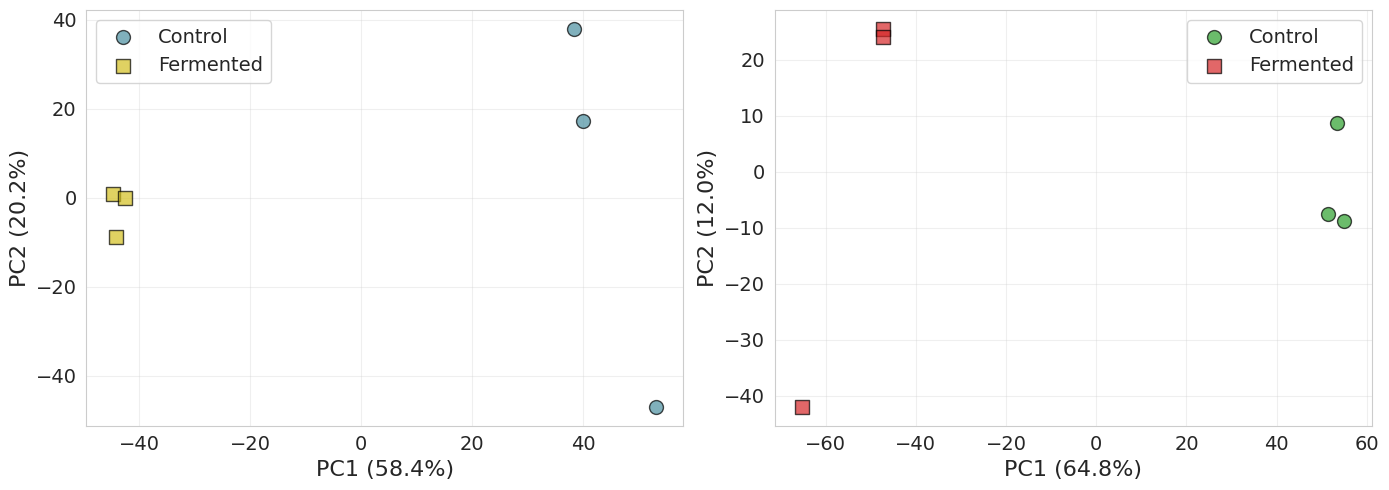

In [5]:
# ── Side-by-side PCA plots ──────────────────────────────────────────────────
# Colors matching pca.ipynb
treatment_colors = {
    'Cassava_Control': '#4A8FA0',
    'Cassava_Fermented': '#D4C020',
    'Cocoyam_Control': '#2ca02c',
    'Cocoyam_Fermented': '#d62728'
}

# Marker shapes: circle for Control, square for Fermented
treatment_markers = {
    'Cassava_Control': 'o',
    'Cassava_Fermented': 's',
    'Cocoyam_Control': 'o',
    'Cocoyam_Fermented': 's'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Cassava PCA ─────────────────────────────────────────────────────────
ax1 = axes[0]
for condition in ['Cassava_Control', 'Cassava_Fermented']:
    data = cassava_pca_df[cassava_pca_df['condition'] == condition]
    label = condition.replace('Cassava_', '')
    ax1.scatter(data['PC1'], data['PC2'], 
                c=treatment_colors[condition], 
                marker=treatment_markers[condition],
                label=label, 
                s=100, alpha=0.7, edgecolors='black', linewidth=1)

ax1.set_xlabel(f"PC1 ({cassava_pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=16)
ax1.set_ylabel(f"PC2 ({cassava_pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
#ax1.set_title('Cassava', fontsize=14, fontweight='bold')
ax1.legend(fontsize=14, loc='best')
ax1.grid(alpha=0.3)

# ── Cocoyam PCA ─────────────────────────────────────────────────────────
ax2 = axes[1]
for condition in ['Cocoyam_Control', 'Cocoyam_Fermented']:
    data = cocoyam_pca_df[cocoyam_pca_df['condition'] == condition]
    label = condition.replace('Cocoyam_', '')
    ax2.scatter(data['PC1'], data['PC2'], 
                c=treatment_colors[condition], 
                marker=treatment_markers[condition],
                label=label, 
                s=100, alpha=0.7, edgecolors='black', linewidth=1)

ax2.set_xlabel(f"PC1 ({cocoyam_pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=16)
ax2.set_ylabel(f"PC2 ({cocoyam_pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=16)
ax2.tick_params(axis='both', labelsize=14)
#ax2.set_title('Cocoyam', fontsize=14, fontweight='bold')
ax2.legend(fontsize=14, loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/pca_sidebyside.svg', format='svg', bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/pca_sidebyside.svg")
plt.show()

Saved: ../figures/separate_treatment/volcano_sidebyside.svg


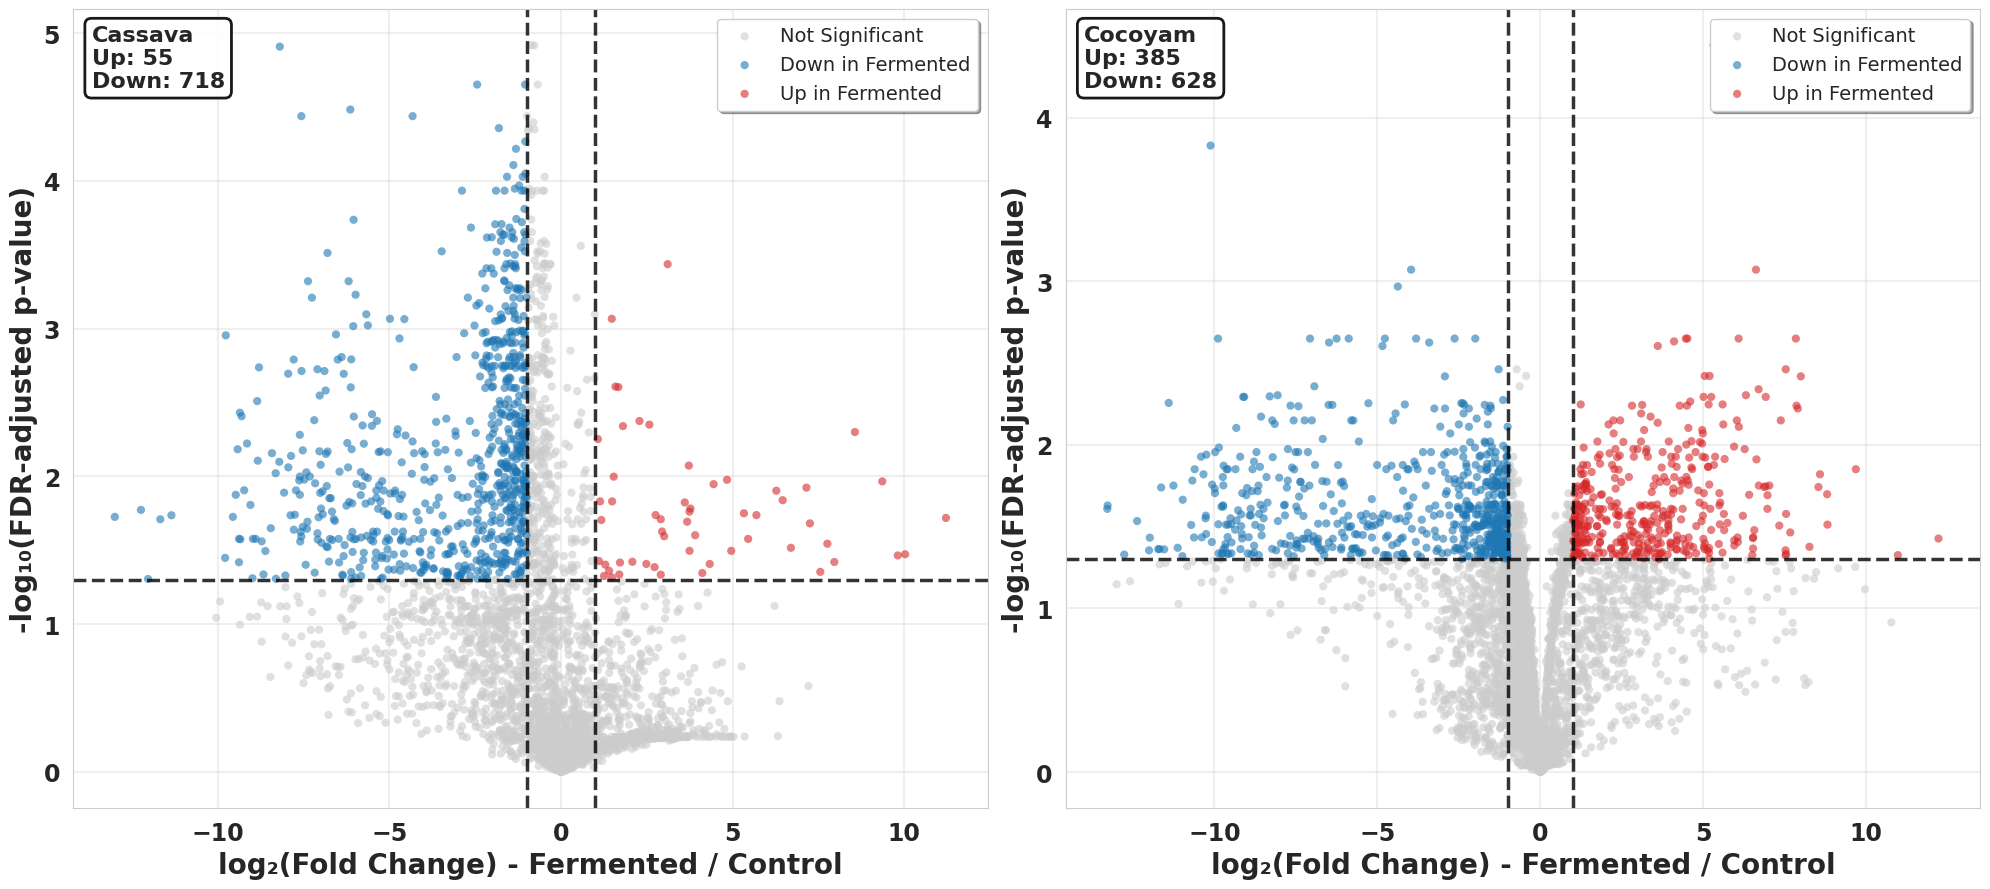

In [6]:
# Side-by-side publication-ready volcano plots
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

datasets = [
    (cassava_fdr.copy(), 'Cassava', axes[0]),
    (cocoyam_fdr.copy(), 'Cocoyam', axes[1])
]

for data, substrate, ax in datasets:
    data['neg_log10_pvalue'] = -np.log10(data['p.value'])
    max_finite = data.loc[np.isfinite(data['neg_log10_pvalue']), 'neg_log10_pvalue'].max()
    data.loc[np.isinf(data['neg_log10_pvalue']), 'neg_log10_pvalue'] = max_finite + 1
    
    data['classification'] = 'Not Significant'
    data.loc[(data['log2FC'] > LOG2FC_THRESHOLD) & (data['p.value'] < FDR_CUTOFF), 'classification'] = 'Up in Fermented'
    data.loc[(data['log2FC'] < -LOG2FC_THRESHOLD) & (data['p.value'] < FDR_CUTOFF), 'classification'] = 'Down in Fermented'
    
    counts = data['classification'].value_counts()
    up_count = counts.get('Up in Fermented', 0)
    down_count = counts.get('Down in Fermented', 0)
    
    colors = {
        'Up in Fermented': '#D62728',
        'Down in Fermented': '#1F77B4',
        'Not Significant': '#CCCCCC'
    }
    
    for category in ['Not Significant', 'Down in Fermented', 'Up in Fermented']:
        subset = data[data['classification'] == category]
        if len(subset) > 0:
            ax.scatter(
                subset['log2FC'], 
                subset['neg_log10_pvalue'],
                c=colors[category],
                label=category,
                alpha=0.6,
                s=35,
                edgecolors='none'
            )
    
    ax.axhline(y=-np.log10(FDR_CUTOFF), color='black', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.axvline(x=LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2.5, alpha=0.8)
    ax.axvline(x=-LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2.5, alpha=0.8)
    
    ax.set_xlabel('log₂(Fold Change) - Fermented / Control', fontsize=20, fontweight='bold')
    ax.set_ylabel('-log₁₀(FDR-adjusted p-value)', fontsize=20, fontweight='bold')
    
    ax.tick_params(axis='both', which='major', labelsize=17, width=2, length=6)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    
    text_str = f'{substrate}\nUp: {up_count:,}\nDown: {down_count:,}'
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes,
            fontsize=16, verticalalignment='top', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
    
    ax.legend(loc='upper right', fontsize=14, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.3, linewidth=1.5)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/volcano_sidebyside.svg', format='svg', bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/volcano_sidebyside.svg")
plt.show()

/tmp/ipykernel_58483/2385689968.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Saved: ../figures/separate_treatment/figure1_complete.svg
✓ Saved: ../figures/separate_treatment/figure1_complete.png


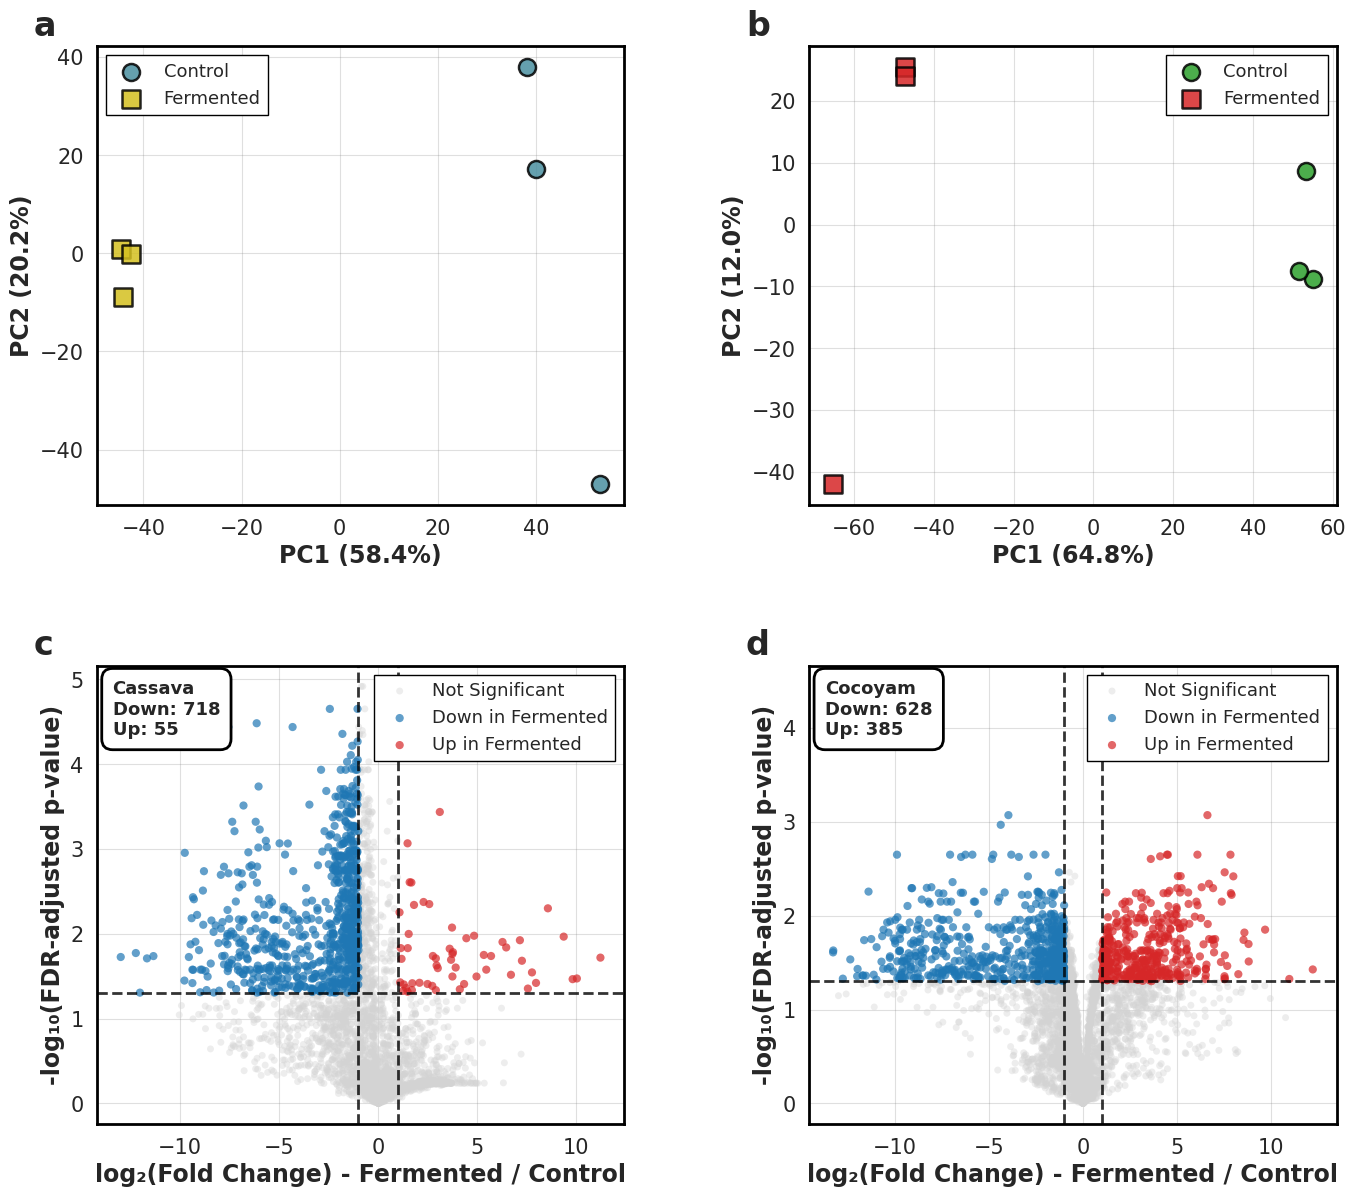

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1: Complete 4-panel figure (PCA + Volcano plots)
# ═══════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 14))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.35)

# Common styling parameters
TITLE_FONTSIZE = 18
LABEL_FONTSIZE = 17
TICK_FONTSIZE = 15
LEGEND_FONTSIZE = 13
PANEL_LABEL_FONTSIZE = 24

# PCA colors and markers (matching your published figure)
pca_colors = {
    'Cassava_Control': '#4A8FA0',
    'Cassava_Fermented': '#D4C020',
    'Cocoyam_Control': '#2ca02c',
    'Cocoyam_Fermented': '#d62728'
}

pca_markers = {
    'Cassava_Control': 'o',
    'Cassava_Fermented': 's',
    'Cocoyam_Control': 'o',
    'Cocoyam_Fermented': 's'
}

# Volcano plot colors
volcano_colors = {
    'Up in Fermented': '#D62728',
    'Down in Fermented': '#1F77B4',
    'Not Significant': '#D3D3D3'
}

# ─────────────────────────────────────────────────────────────────────────
# PANEL A: Cassava PCA
# ─────────────────────────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])

for condition in ['Cassava_Control', 'Cassava_Fermented']:
    data = cassava_pca_df[cassava_pca_df['condition'] == condition]
    label = condition.replace('Cassava_', '')
    ax_a.scatter(data['PC1'], data['PC2'], 
                c=pca_colors[condition], 
                marker=pca_markers[condition],
                label=label, 
                s=150, alpha=0.85, edgecolors='black', linewidth=1.8)

ax_a.set_xlabel(f"PC1 ({cassava_pca.explained_variance_ratio_[0]*100:.1f}%)", 
               fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_a.set_ylabel(f"PC2 ({cassava_pca.explained_variance_ratio_[1]*100:.1f}%)", 
               fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_a.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=2, length=6)
ax_a.legend(fontsize=LEGEND_FONTSIZE, loc='best', frameon=True, 
           fancybox=False, edgecolor='black', framealpha=1, shadow=False)
ax_a.grid(True, alpha=0.25, linewidth=0.8, linestyle='-', color='gray')
ax_a.set_axisbelow(True)
# Spines styling
for spine in ax_a.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
ax_a.text(-0.12, 1.08, 'a', transform=ax_a.transAxes, 
         fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────
# PANEL B: Cocoyam PCA
# ─────────────────────────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])

for condition in ['Cocoyam_Control', 'Cocoyam_Fermented']:
    data = cocoyam_pca_df[cocoyam_pca_df['condition'] == condition]
    label = condition.replace('Cocoyam_', '')
    ax_b.scatter(data['PC1'], data['PC2'], 
                c=pca_colors[condition], 
                marker=pca_markers[condition],
                label=label, 
                s=150, alpha=0.85, edgecolors='black', linewidth=1.8)

ax_b.set_xlabel(f"PC1 ({cocoyam_pca.explained_variance_ratio_[0]*100:.1f}%)", 
               fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_b.set_ylabel(f"PC2 ({cocoyam_pca.explained_variance_ratio_[1]*100:.1f}%)", 
               fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_b.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=2, length=6)
ax_b.legend(fontsize=LEGEND_FONTSIZE, loc='best', frameon=True,
           fancybox=False, edgecolor='black', framealpha=1, shadow=False)
ax_b.grid(True, alpha=0.25, linewidth=0.8, linestyle='-', color='gray')
ax_b.set_axisbelow(True)
# Spines styling
for spine in ax_b.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
ax_b.text(-0.12, 1.08, 'b', transform=ax_b.transAxes, 
         fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────
# PANEL C: Cassava Volcano Plot
# ─────────────────────────────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])

cassava_volcano = cassava_fdr.copy()
cassava_volcano['neg_log10_pvalue'] = -np.log10(cassava_volcano['p.value'])
max_finite = cassava_volcano.loc[np.isfinite(cassava_volcano['neg_log10_pvalue']), 'neg_log10_pvalue'].max()
cassava_volcano.loc[np.isinf(cassava_volcano['neg_log10_pvalue']), 'neg_log10_pvalue'] = max_finite + 1

cassava_volcano['classification'] = 'Not Significant'
cassava_volcano.loc[(cassava_volcano['log2FC'] > LOG2FC_THRESHOLD) & 
                   (cassava_volcano['p.value'] < FDR_CUTOFF), 'classification'] = 'Up in Fermented'
cassava_volcano.loc[(cassava_volcano['log2FC'] < -LOG2FC_THRESHOLD) & 
                   (cassava_volcano['p.value'] < FDR_CUTOFF), 'classification'] = 'Down in Fermented'

counts_cassava = cassava_volcano['classification'].value_counts()
up_cassava = counts_cassava.get('Up in Fermented', 0)
down_cassava = counts_cassava.get('Down in Fermented', 0)

for category in ['Not Significant', 'Down in Fermented', 'Up in Fermented']:
    subset = cassava_volcano[cassava_volcano['classification'] == category]
    if len(subset) > 0:
        alpha_val = 0.4 if category == 'Not Significant' else 0.7
        s_val = 25 if category == 'Not Significant' else 35
        ax_c.scatter(subset['log2FC'], subset['neg_log10_pvalue'],
                    c=volcano_colors[category], label=category,
                    alpha=alpha_val, s=s_val, edgecolors='none')

ax_c.axhline(y=-np.log10(FDR_CUTOFF), color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
ax_c.axvline(x=LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
ax_c.axvline(x=-LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)

ax_c.set_xlabel('log₂(Fold Change) - Fermented / Control', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_c.set_ylabel('-log₁₀(FDR-adjusted p-value)', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_c.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=2, length=6)

text_str = f'Cassava\nDown: {down_cassava:,}\nUp: {up_cassava:,}'
ax_c.text(0.03, 0.97, text_str, transform=ax_c.transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=1, 
                  edgecolor='black', linewidth=2))

ax_c.legend(loc='upper right', fontsize=LEGEND_FONTSIZE, frameon=True,
           fancybox=False, edgecolor='black', framealpha=1, shadow=False)
ax_c.grid(True, alpha=0.25, linewidth=0.8, linestyle='-', color='gray')
ax_c.set_axisbelow(True)
# Spines styling
for spine in ax_c.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
ax_c.text(-0.12, 1.08, 'c', transform=ax_c.transAxes, 
         fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────
# PANEL D: Cocoyam Volcano Plot
# ─────────────────────────────────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])

cocoyam_volcano = cocoyam_fdr.copy()
cocoyam_volcano['neg_log10_pvalue'] = -np.log10(cocoyam_volcano['p.value'])
max_finite = cocoyam_volcano.loc[np.isfinite(cocoyam_volcano['neg_log10_pvalue']), 'neg_log10_pvalue'].max()
cocoyam_volcano.loc[np.isinf(cocoyam_volcano['neg_log10_pvalue']), 'neg_log10_pvalue'] = max_finite + 1

cocoyam_volcano['classification'] = 'Not Significant'
cocoyam_volcano.loc[(cocoyam_volcano['log2FC'] > LOG2FC_THRESHOLD) & 
                   (cocoyam_volcano['p.value'] < FDR_CUTOFF), 'classification'] = 'Up in Fermented'
cocoyam_volcano.loc[(cocoyam_volcano['log2FC'] < -LOG2FC_THRESHOLD) & 
                   (cocoyam_volcano['p.value'] < FDR_CUTOFF), 'classification'] = 'Down in Fermented'

counts_cocoyam = cocoyam_volcano['classification'].value_counts()
up_cocoyam = counts_cocoyam.get('Up in Fermented', 0)
down_cocoyam = counts_cocoyam.get('Down in Fermented', 0)

for category in ['Not Significant', 'Down in Fermented', 'Up in Fermented']:
    subset = cocoyam_volcano[cocoyam_volcano['classification'] == category]
    if len(subset) > 0:
        alpha_val = 0.4 if category == 'Not Significant' else 0.7
        s_val = 25 if category == 'Not Significant' else 35
        ax_d.scatter(subset['log2FC'], subset['neg_log10_pvalue'],
                    c=volcano_colors[category], label=category,
                    alpha=alpha_val, s=s_val, edgecolors='none')

ax_d.axhline(y=-np.log10(FDR_CUTOFF), color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
ax_d.axvline(x=LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)
ax_d.axvline(x=-LOG2FC_THRESHOLD, color='black', linestyle='--', linewidth=2, alpha=0.8, zorder=1)

ax_d.set_xlabel('log₂(Fold Change) - Fermented / Control', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_d.set_ylabel('-log₁₀(FDR-adjusted p-value)', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_d.tick_params(axis='both', labelsize=TICK_FONTSIZE, width=2, length=6)

text_str = f'Cocoyam\nDown: {down_cocoyam:,}\nUp: {up_cocoyam:,}'
ax_d.text(0.03, 0.97, text_str, transform=ax_d.transAxes,
         fontsize=13, verticalalignment='top', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=1, 
                  edgecolor='black', linewidth=2))

ax_d.legend(loc='upper right', fontsize=LEGEND_FONTSIZE, frameon=True,
           fancybox=False, edgecolor='black', framealpha=1, shadow=False)
ax_d.grid(True, alpha=0.25, linewidth=0.8, linestyle='-', color='gray')
ax_d.set_axisbelow(True)
# Spines styling
for spine in ax_d.spines.values():
    spine.set_linewidth(2)
    spine.set_edgecolor('black')
ax_d.text(-0.12, 1.08, 'd', transform=ax_d.transAxes, 
         fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ─────────────────────────────────────────────────────────────────────────
# Save figure
# ─────────────────────────────────────────────────────────────────────────
plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/figure1_complete.svg', format='svg', bbox_inches='tight', dpi=300)
fig.savefig(f'{OUTPUT_DIR}/figure1_complete.png', format='png', bbox_inches='tight', dpi=300)
print(f"✓ Saved: {OUTPUT_DIR}/figure1_complete.svg")
print(f"✓ Saved: {OUTPUT_DIR}/figure1_complete.png")
plt.show()